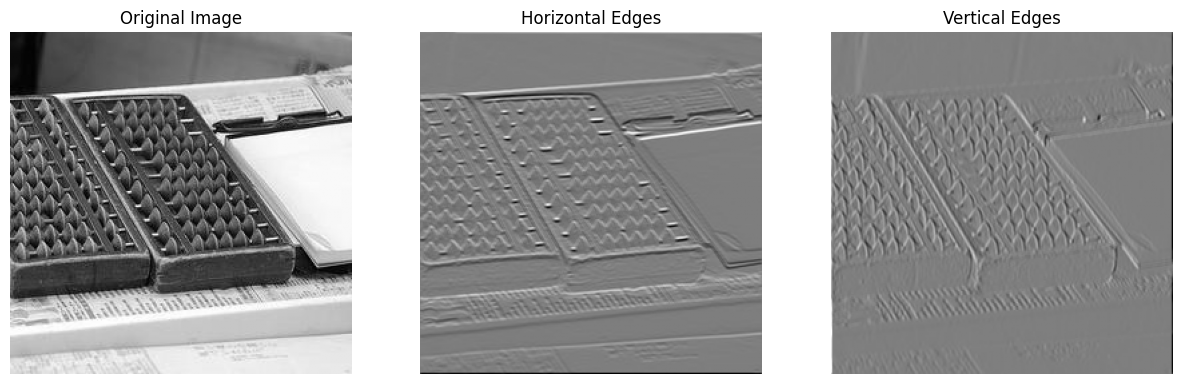

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def load_image(image_path):
    img = Image.open(image_path).convert('L')
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    img_tensor = transform(img).unsqueeze(0)
    return img, img_tensor


kernel_h = torch.tensor([[-1., -1., -1.],
                         [ 0.,  0.,  0.],
                         [ 1.,  1.,  1.]])


kernel_v = torch.tensor([[-1.,  0.,  1.],
                         [-1.,  0.,  1.],
                         [-1.,  0.,  1.]])


kernel_h = kernel_h.view(1, 1, 3, 3);
kernel_v = kernel_v.view(1, 1, 3, 3);

def apply_convolution(img_tensor, kernel):
    output = F.conv2d(img_tensor, kernel, padding=1)
    return output



image_path = '009.jpg'

try:
    original_img, img_tensor = load_image(image_path)

    output_h = apply_convolution(img_tensor, kernel_h)

    output_v = apply_convolution(img_tensor, kernel_v)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(output_h.squeeze().detach().numpy(), cmap='gray')
    plt.title("Horizontal Edges")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(output_v.squeeze().detach().numpy(), cmap='gray')
    plt.title("Vertical Edges")
    plt.axis('off')

    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{image_path}' was not found. Please upload an image and update the 'image_path' variable.")